**Assignment 4: Regularization**

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

**Question 1**

1. Adding a penalty to MSE allows the model to both reduce prediction error, and also trying to avoid having very large coefficients. The penalty makes large coefficients “cost” more, so the model only keeps them if they are actually useful for prediction. The intuition is that large coefficients can make the model too sensitive to small changes in the data, which increases variance and can cause overfitting. By shrinking the coefficients toward 0, regularization makes the model simpler and more stable. This may slightly increase bias, but it helps reduce variance and makes the model more reliable on new data.

2. Regularization changes how strongly the model is penalized for large coefficients. If the penalty is small, the model is closer to regular linear regression. It can fit the training data more closely, so it has lower bias but higher variance. if the penalty is large, the coefficients shrink closer to 0. The model becomes simpler. This increases bias a little, but lowers variance because the predictions become less sensitive to changes in the data.

3. LASSO uses the absolute values of the coefficients as the penalty, while Ridge uses the squared values of the coefficients. Because of this, LASSO can shrink some coefficients exactly to 0, allowing it to remove certain variables completely. Ridge shrinks coefficients toward 0, but usually does not make them exactly 0. As a result, LASSO typically gives a model with only a smaller set of selected predictors, while Ridge usually keeps all predictors in the model but reduces their influence.

4. For regularized regression, we z-score the quantitative variables so they are on a comparable scale, because the penalty acts on coefficient size. We typically z-score the quantitative predictors before regularized regression by subtracting the mean and dividing by the standard deviation.

5. We use cross-validation to find the value that gives the best predictive performance.

6. No. The penalty is used only to fit the model on training data. Cross-validation measures predictive performance on new data, so we use the ordinary MSE on the validation set.

**Question 2**

1. 

In [58]:
df = pd.read_csv('cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [59]:
df["Age"] = 2026 - df["Make_Year"]
X = df[["Mileage_Run", "Age"]]


In [60]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [61]:
#polynomial features
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

X_poly = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(["Mileage_Run", "Age"]))

#normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


X_scaled = pd.DataFrame(X_scaled, columns=X_poly.columns)
X_scaled.head()

,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,0.124692,-0.013092,-0.137673,-0.045119,-0.157264,-0.294615,-0.230767,-0.195586,-0.270422
1,-0.872334,0.341858,-0.791316,-0.677034,0.190081,-0.661216,-0.718186,-0.564890,0.044089
2,-0.493517,-0.722993,-0.600623,-0.665157,-0.742267,-0.581863,-0.648004,-0.700911,-0.718398
3,-0.241655,-0.013092,-0.434732,-0.301067,-0.157264,-0.492295,-0.458906,-0.364354,-0.270422
4,-0.674578,-0.013092,-0.700583,-0.603528,-0.157264,-0.627064,-0.663078,-0.563792,-0.270422


2. 

In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
y = df["Price"]

#linear regression
lr = LinearRegression()
lr.fit(X_scaled, y)

coef = pd.Series(lr.coef_, index=X_scaled.columns)


print(coef)

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64


In [64]:
print("Interaction coefficient:", coef["Mileage_Run Age"])

Interaction coefficient: -1671212.356391895


3. 

In [65]:
from sklearn.linear_model import LassoCV

In [66]:
alphas = np.logspace(1,3,20)

reg = LassoCV(alphas=alphas, cv=20)
reg.fit(X_scaled, y)

print(reg.alpha_)

69.51927961775606


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

4. 

In [74]:
cv_mse = reg.mse_path_.mean(axis=1)

mse_df = pd.DataFrame({
    "alpha": reg.alphas_,
    "cv_mse": cv_mse
})

print(f"Optimal cost hyperparameter: {reg.alpha_}")

Optimal cost hyperparameter: 69.51927961775606


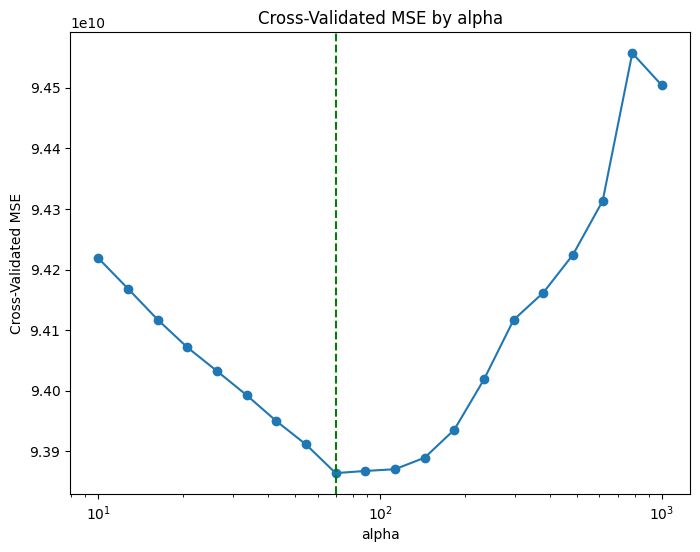

In [75]:
# plot
plt.figure(figsize=(8,6))
plt.plot(mse_df["alpha"], mse_df["cv_mse"], marker="o")
plt.axvline(x=reg.alpha_, color="green", linestyle="--", linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("Cross-Validated MSE by alpha")
plt.show()

5. 

In [53]:
from sklearn.linear_model import lasso_path

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.435e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.874e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

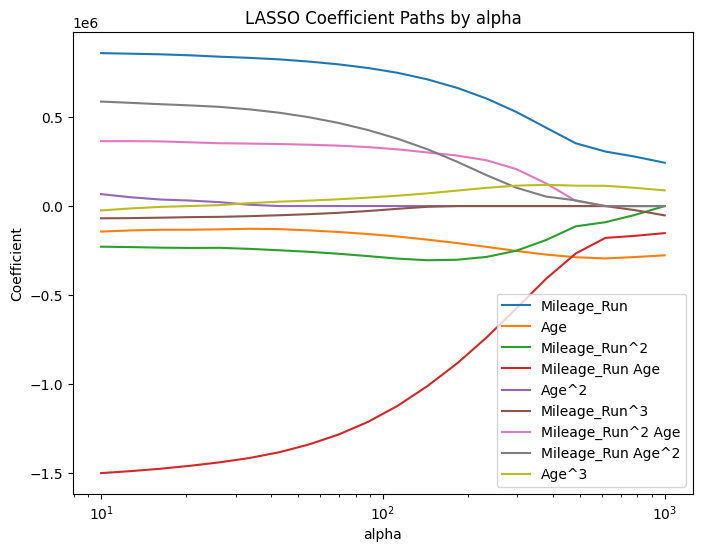

In [54]:
#lasso coefficient paths
alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y, alphas=alphas)

#plot
plt.figure(figsize=(8,6))

for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i], label=X_scaled.columns[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths by alpha")
plt.legend()
plt.show()

6.

In [76]:
coef = pd.Series(reg.coef_, index=X_scaled.columns)

print("Selected features:")
print(coef[coef != 0])

print("\nProportion set equal to zero:")
print((coef == 0).mean())

Selected features:
Mileage_Run          611783.868767
Age                 -397507.787042
Mileage_Run^2       -519555.261867
Mileage_Run Age     -473871.400459
Age^2                230721.078724
Mileage_Run^3         97835.641353
Mileage_Run^2 Age    318218.774588
Mileage_Run Age^2    -35056.210190
Age^3                 42493.187416
dtype: float64

Proportion set equal to zero:
0.0
